# Belebele baseline results

900 matched questions in English and Ukrainian, evaluated on both models. Zero-shot prompts use an English instruction in both languages. The answer is the highest-scoring next token among A/B/C/D; this is constrained answer-choice scoring, not free-form answer generation.

Inputs and answers load from immutable HF revisions in `configs/artifacts.json`. Private repository access requires organization membership and `hf auth login`.

In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download, snapshot_download
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", 20)
SAFETY_RUN = "2131659-limit0-b8-t2048"
UTILITY_RUN = "2131431-limit0"
MODELS = ["gemma", "lapa"]
artifacts = json.loads((ROOT / "configs/artifacts.json").read_text())
answer_config = artifacts["model_answers"]
answer_dir = Path(
    snapshot_download(
        repo_id=answer_config["repo_id"],
        repo_type="dataset",
        revision=answer_config["revision"],
        allow_patterns=["manifest.json", "safety/*.jsonl", "belebele/*.jsonl"],
    )
)
manifest_path = answer_dir / "manifest.json"
assert (
    hashlib.sha256(manifest_path.read_bytes()).hexdigest()
    == answer_config["manifest_sha256"]
)
manifest = json.loads(manifest_path.read_text())
for item in manifest["files"]:
    assert (
        hashlib.sha256((answer_dir / item["path"]).read_bytes()).hexdigest()
        == item["sha256"]
    )
print("Answers:", answer_config["repo_id"], answer_config["revision"])

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Answers: steering-transfer/model-answers 8a5a679f942f381ae56e2ed21514bead1ee7ec8b


## Verify predictions and answer keys

Every prediction is checked against the frozen dataset, and every stored correctness flag is recomputed.

In [2]:
parts = []
metadata = []
for model in MODELS:
    part = pd.read_json(answer_dir / "belebele" / f"{model}.jsonl", lines=True)
    info = next(
        row
        for row in manifest["runs"]
        if row["task"] == "belebele" and row["model"] == model
    )
    assert len(part) == info["records"] == 1800 and part.model.eq(model).all()
    assert info["scoring"] == "next_token_argmax_ABCD"
    parts.append(part)
    metadata.append(
        {
            "model": model,
            "revision": info["revision"],
            "input_sha256": info["input_sha256"],
        }
    )
utility = pd.concat(parts, ignore_index=True)
keys = ["model", "language", "link", "question_number"]
assert len(utility) == 3600 and not utility.duplicated(keys).any()
assert utility.prediction.isin(list("ABCD")).all()
assert utility.answer.isin(list("ABCD")).all()
assert utility.correct.eq(utility.prediction.eq(utility.answer)).all()
revision = "7899cdfa4e1e0d733fd77c848e2c273cb1d32be2"
datasets = []
for language in ["eng_Latn", "ukr_Cyrl"]:
    path = Path(
        hf_hub_download(
            repo_id="facebook/belebele",
            repo_type="dataset",
            revision=revision,
            filename=f"data/{language}.jsonl",
        )
    )
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    assert all(row["input_sha256"][language] == digest for row in metadata)
    part = pd.read_json(path, lines=True)
    assert len(part) == 900 and not part.duplicated(["link", "question_number"]).any()
    datasets.append(part.assign(language=language))
questions = pd.concat(datasets, ignore_index=True)
answer_keys = questions.set_index(
    ["language", "link", "question_number"]
).correct_answer_num
answer_keys = answer_keys.astype(int).map(dict(enumerate("ABCD", 1)))
for (model, language), group in utility.groupby(["model", "language"]):
    assert len(group) == 900
    actual = group.set_index(["language", "link", "question_number"]).answer
    assert set(actual.index) == set(answer_keys.loc[[language]].index)
    assert actual.eq(answer_keys.reindex(actual.index)).all()
probabilities = pd.DataFrame(utility.label_probabilities.tolist(), index=utility.index)
assert np.isfinite(probabilities.to_numpy()).all()
assert probabilities.ge(0).all().all() and probabilities.le(1).all().all()
assert np.allclose(probabilities.sum(axis=1), 1, atol=1e-6)
assert probabilities.idxmax(axis=1).eq(utility.prediction).all()
utility["choice_probability"] = probabilities.max(axis=1)
display(pd.DataFrame(metadata).drop(columns="input_sha256"))

,model,revision
0,gemma,96b6f1eccf38110c56df3a15bffe176da04bfd80
1,lapa,2969fd997f07b33727c6f10795d78ef23cc5c037


questions  correct  accuracy  accuracy_pct
model language                                            
gemma eng_Latn        900      844     0.938        93.778
      ukr_Cyrl        900      813     0.903        90.333
lapa  eng_Latn        900      826     0.918        91.778
      ukr_Cyrl        900      797     0.886        88.556

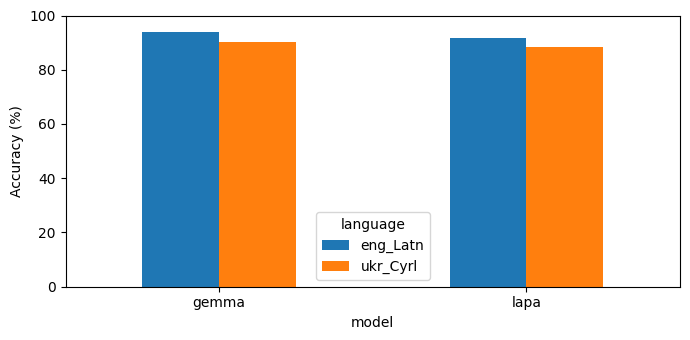

In [3]:
accuracy = utility.groupby(["model", "language"]).agg(
    questions=("correct", "size"),
    correct=("correct", "sum"),
    accuracy=("correct", "mean"),
)
accuracy["accuracy_pct"] = 100 * accuracy.accuracy
display(accuracy.round(3))
accuracy.accuracy_pct.unstack("language").plot.bar(
    rot=0, ylim=(0, 100), figsize=(7, 3.5), ylabel="Accuracy (%)"
)
plt.tight_layout()
plt.show()

## Paired language outcomes

Rows match on `(link, question_number)`. The language gap is Ukrainian accuracy minus English accuracy on the same questions.

In [4]:
paired = utility.pivot(
    index=["model", "link", "question_number"], columns="language", values="correct"
)
paired["outcome"] = np.select(
    [
        paired.eng_Latn & paired.ukr_Cyrl,
        paired.eng_Latn & ~paired.ukr_Cyrl,
        ~paired.eng_Latn & paired.ukr_Cyrl,
    ],
    ["both correct", "English only", "Ukrainian only"],
    default="both wrong",
)
display(pd.crosstab(paired.index.get_level_values("model"), paired.outcome))
display(
    (paired.ukr_Cyrl.astype(int) - paired.eng_Latn.astype(int))
    .groupby("model")
    .mean()
    .mul(100)
    .rename("Ukrainian minus English (percentage points)")
)

outcome,English only,Ukrainian only,both correct,both wrong
row_0,,,,
gemma,41,10,803,46
lapa,45,16,781,58


model
gemma   -3.444444
lapa    -3.222222
Name: Ukrainian minus English (percentage points), dtype: float64

## Compare models on matched questions

Count questions solved by both models, by only one model, or by neither. The same question-language pairs are compared; these are not independent samples.

In [5]:
model_pairs = utility.pivot(
    index=["language", "link", "question_number"], columns="model", values="correct"
)
model_pairs["outcome"] = np.select(
    [
        model_pairs.gemma & model_pairs.lapa,
        model_pairs.gemma & ~model_pairs.lapa,
        ~model_pairs.gemma & model_pairs.lapa,
    ],
    ["both correct", "Gemma only", "Lapa only"],
    default="both wrong",
)
display(
    pd.crosstab(model_pairs.index.get_level_values("language"), model_pairs.outcome)
)

outcome,Gemma only,Lapa only,both correct,both wrong
row_0,,,,
eng_Latn,29,11,815,45
ukr_Cyrl,43,27,770,60


## Choice scores and errors

The saved softmax is normalized only over A/B/C/D. It is not a calibrated probability of correctness. Large values can accompany wrong answers.

In [6]:
display(
    utility.groupby(["model", "language", "correct"])
    .choice_probability.agg(["size", "median", "min"])
    .round(4)
)
display(pd.crosstab([utility.model, utility.language], utility.prediction))
display(pd.crosstab([utility.model, utility.language], utility.answer))

size  median     min
model language correct                      
gemma eng_Latn False      56  0.9995  0.5621
               True      844  1.0000  0.5613
      ukr_Cyrl False      87  0.9985  0.3467
               True      813  1.0000  0.6791
lapa  eng_Latn False      74  1.0000  0.5761
               True      826  1.0000  0.6037
      ukr_Cyrl False     103  1.0000  0.6224
               True      797  1.0000  0.7311

prediction        A    B    C    D
model language                    
gemma eng_Latn  204  251  244  201
      ukr_Cyrl  217  245  237  201
lapa  eng_Latn  200  238  230  232
      ukr_Cyrl  200  235  228  237

answer            A    B    C    D
model language                    
gemma eng_Latn  206  251  246  197
      ukr_Cyrl  206  251  246  197
lapa  eng_Latn  206  251  246  197
      ukr_Cyrl  206  251  246  197

In [7]:
scored = utility.merge(
    questions, on=["language", "link", "question_number"], validate="many_to_one"
)
scored["question_chars"] = scored.question.str.len()
scored["passage_chars"] = scored.flores_passage.str.len()
scored["passage_length_quartile"] = scored.groupby("language").passage_chars.transform(
    lambda x: pd.qcut(x, 4, labels=False, duplicates="drop")
)
display(
    scored.groupby(["model", "language", "passage_length_quartile"])
    .correct.agg(["size", "mean"])
    .round(3)
)

size   mean
model language passage_length_quartile             
gemma eng_Latn 0                         225  0.933
               1                         226  0.942
               2                         225  0.924
               3                         224  0.951
      ukr_Cyrl 0                         227  0.899
               1                         226  0.912
               2                         223  0.892
               3                         224  0.911
lapa  eng_Latn 0                         225  0.924
               1                         226  0.929
               2                         225  0.884
               3                         224  0.933
      ukr_Cyrl 0                         227  0.890
               1                         226  0.889
               2                         223  0.852
               3                         224  0.911

## Read matched questions and model errors

The first example is a seeded error. The browser provides complete passages, questions, options, predictions, and answer keys for both languages.

In [8]:
example = scored.loc[~scored.correct].sample(n=1, random_state=42).iloc[0]
example_id = (example.link, int(example.question_number))
for row in (
    scored.loc[scored.link.eq(example_id[0]) & scored.question_number.eq(example_id[1])]
    .sort_values(["language", "model"])
    .itertuples()
):
    print(
        f"\n{row.model} | {row.language} | predicted {row.prediction} | answer {row.answer}"
    )
    print("PASSAGE:", row.flores_passage)
    print("QUESTION:", row.question)
    for label, option in zip(
        "ABCD",
        [row.mc_answer1, row.mc_answer2, row.mc_answer3, row.mc_answer4],
        strict=True,
    ):
        print(label + ": " + option)


gemma | eng_Latn | predicted A | answer D
PASSAGE: The disadvantage of zoom lenses is that the focal complexity and number of lens elements required to achieve a range of focal lengths is much greater than for prime lenses. This is becoming less of an issue as lens manufacturers achieve higher standards in lens production. This has allowed zoom lenses to produce pictures of a quality comparable to that achieved by lenses with fixed focal length. Another disadvantage of zoom lenses is that the maximum aperture (the speed) of the lens is usually lower. This makes inexpensive zoom lenses hard to use in low-light conditions without a flash.
QUESTION: Based on the information in the passage, when might a zoom lens be preferable to a prime lens?
A: If a high maximum aperture is a priority
B: If you want less lens elements
C: If you don’t want to use a flash in darker settings
D: If you’re looking for more focal complexity

lapa | eng_Latn | predicted D | answer D
PASSAGE: The disadvantage o

In [9]:
import ipywidgets as widgets

question_ids = (
    questions[["link", "question_number"]]
    .drop_duplicates()
    .sort_values(["link", "question_number"])
)
options = [
    (
        f"{i}: {row.link.rsplit('/', 1)[-1]} / Q{row.question_number}",
        (row.link, int(row.question_number)),
    )
    for i, row in enumerate(question_ids.itertuples(index=False))
]
choice = widgets.Dropdown(
    options=options,
    value=example_id,
    description="Question",
    layout=widgets.Layout(width="95%"),
)


def read_question(question_id):
    link, number = question_id
    rows = scored.loc[scored.link.eq(link) & scored.question_number.eq(number)]
    for language, group in rows.groupby("language"):
        row = group.iloc[0]
        print("\n" + language + "\nPASSAGE:\n" + row.flores_passage)
        print("QUESTION:\n" + row.question)
        for label, option in zip(
            "ABCD",
            row[["mc_answer1", "mc_answer2", "mc_answer3", "mc_answer4"]],
            strict=True,
        ):
            print(label + ": " + option)
        print("ANSWER:", row.answer)
        print(
            group[["model", "prediction", "correct", "choice_probability"]].to_string(
                index=False
            )
        )


display(choice, widgets.interactive_output(read_question, {"question_id": choice}))

Dropdown(description='Question', index=120, layout=Layout(width='95%'), options=(('0: Right_hand / Q1', ('http…

Output()